# Show, Attend and Tell: Neural Image Caption Generation with Visual Attention

**Reproduction du papier de Xu et al., ICML 2015**  
Dataset : Flickr8k | Modèles : VGG19 + Soft Attention (SAT) vs Show and Tell (baseline)

---
## ⚠️ Configuration requise avant de lancer

1. Télécharger Flickr8k depuis Kaggle : https://www.kaggle.com/datasets/adityajn105/flickr8k
2. Extraire dans un dossier local, ex : `C:\Users\RACHID\Downloads\flickr8k\`
3. La structure attendue :
```
flickr8k/
  Images/        ← toutes les images .jpg
  captions.txt   ← fichier des légendes
```
4. Mettre à jour `IMAGE_DIR` et `CAPTION_FILE` dans la Cellule 2 ci-dessous.

## Cellule 1 — Installation et imports

Installe les dépendances manquantes et importe toutes les bibliothèques nécessaires.  
PyTorch fournit le framework deep learning. NLTK est utilisé pour la tokenisation et le calcul du score BLEU.

In [1]:
# ============================================================
# CELL 1 - Installation et imports
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "nltk", "-q"])

import os
import random
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Vérification du device (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
print(f"PyTorch version : {torch.__version__}")

Device utilisé : cuda
PyTorch version : 2.5.1+cu121


## Cellule 2 — Configuration des chemins

**⚠️ Modifier les chemins ci-dessous selon votre machine.**  
Télécharger Flickr8k depuis : https://www.kaggle.com/datasets/adityajn105/flickr8k

In [2]:
# ============================================================
# CELL 2 - Configuration des chemins locaux
# ============================================================

# ⚠️ MODIFIER CES DEUX CHEMINS selon votre installation :
IMAGE_DIR    = r"C:\Users\RACHID\Documents\4DS5\deep l\deepl\Images"
CAPTION_FILE = r"C:\Users\RACHID\Documents\4DS5\deep l\deepl\captions.txt"

# Dossier de sauvegarde des modèles et figures
OUTPUT_DIR   = r"C:\Users\RACHID\Documents\4DS5\deep l\deepl\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Vérification
if not os.path.exists(IMAGE_DIR):
    print(f"❌ IMAGE_DIR introuvable : {IMAGE_DIR}")
    print("   → Modifiez le chemin ci-dessus.")
elif not os.path.exists(CAPTION_FILE):
    print(f"❌ CAPTION_FILE introuvable : {CAPTION_FILE}")
    print("   → Modifiez le chemin ci-dessus.")
else:
    n_images = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
    print(f"✅ Dataset trouvé : {n_images} images dans {IMAGE_DIR}")
    print(f"✅ Fichier captions : {CAPTION_FILE}")
    print(f"✅ Outputs sauvegardés dans : {OUTPUT_DIR}")

✅ Dataset trouvé : 8091 images dans C:\Users\RACHID\Documents\4DS5\deep l\deepl\Images
✅ Fichier captions : C:\Users\RACHID\Documents\4DS5\deep l\deepl\captions.txt
✅ Outputs sauvegardés dans : C:\Users\RACHID\Documents\4DS5\deep l\deepl\outputs


## Cellule 3 — Vocabulaire et chargement des captions

La classe `Vocabulary` construit un dictionnaire mot→indice à partir des légendes.  
Tokens spéciaux : `<PAD>` (rembourrage), `<SOS>` (début), `<EOS>` (fin), `<UNK>` (mot inconnu).  
Seuls les mots apparaissant au moins `freq_threshold` fois sont conservés (filtre le bruit).

Le dataset est découpé en **6000 train / 1000 val / ~1091 test** (standard Flickr8k).

In [3]:
# ============================================================
# CELL 3 - Vocabulaire et chargement des captions
# ============================================================

class Vocabulary:
    """Gère le mapping mot <-> indice pour le modèle."""

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    def tokenize(self, text):
        """Tokenise un texte en liste de mots en minuscules."""
        return nltk.tokenize.word_tokenize(text.lower())

    def build_vocab(self, sentence_list):
        """Construit le vocabulaire à partir d'une liste de phrases."""
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx]  = word
                    idx += 1

    def numericalize(self, text):
        """Convertit une phrase en liste d'indices."""
        tokens = self.tokenize(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokens]


def load_captions(caption_file):
    """Charge le fichier captions.txt de Flickr8k."""
    captions = {}
    with open(caption_file, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i == 0:   # skip header
                continue
            parts = line.strip().split(",", 1)
            if len(parts) != 2:
                continue
            img_name, caption = parts
            img_name = img_name.split("#")[0].strip()
            caption  = caption.strip()
            if img_name not in captions:
                captions[img_name] = []
            captions[img_name].append(caption)
    return captions


# Chargement
captions_dict = load_captions(CAPTION_FILE)

# Construction du vocabulaire
all_captions = [cap for caps in captions_dict.values() for cap in caps]
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocab(all_captions)
print(f"Taille du vocabulaire : {len(vocab)} mots")

# Split train / val / test
all_images = list(captions_dict.keys())
random.seed(42)
random.shuffle(all_images)
train_imgs = all_images[:6000]
val_imgs   = all_images[6000:7000]
test_imgs  = all_images[7000:]
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

Taille du vocabulaire : 3006 mots
Train: 6000 | Val: 1000 | Test: 1091


## Cellule 4 — Dataset et DataLoader

`Flickr8kDataset` hérite de `torch.utils.data.Dataset` et retourne un couple (image, caption numericalisée).  
La fonction `collate_fn` aligne les séquences de longueurs différentes avec du padding (`<PAD>`).  
Les images sont redimensionnées à **224×224** et normalisées avec les stats ImageNet.

In [4]:
# ============================================================
# CELL 4 - Dataset et DataLoader
# ============================================================

class Flickr8kDataset(Dataset):
    """Dataset Flickr8k : retourne (image_tensor, caption_tensor) par item."""

    def __init__(self, image_dir, captions_dict, image_list, vocab, transform=None):
        self.image_dir     = image_dir
        self.captions_dict = captions_dict
        self.image_list    = image_list
        self.vocab         = vocab
        self.transform     = transform
        # Un item par paire (image, caption)
        self.data = []
        for img in image_list:
            for cap in captions_dict[img]:
                self.data.append((img, cap))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        tokens = ([self.vocab.stoi["<SOS>"]] +
                  self.vocab.numericalize(caption) +
                  [self.vocab.stoi["<EOS>"]])
        return image, torch.tensor(tokens, dtype=torch.long)


def collate_fn(batch):
    """Padding dynamique pour les séquences de longueurs variables."""
    images, captions = zip(*batch)
    images   = torch.stack(images, 0)
    lengths  = [len(c) for c in captions]
    max_len  = max(lengths)
    padded   = torch.zeros(len(captions), max_len).long()
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)


# Transformations images (normalisation ImageNet standard)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = Flickr8kDataset(IMAGE_DIR, captions_dict, train_imgs, vocab, transform)
val_dataset   = Flickr8kDataset(IMAGE_DIR, captions_dict, val_imgs,   vocab, transform)
test_dataset  = Flickr8kDataset(IMAGE_DIR, captions_dict, test_imgs,  vocab, transform)

# num_workers=0 pour compatibilité Windows (évite les erreurs multiprocessing)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches - Train: 938 | Val: 157 | Test: 171


## Cellule 5 — Encodeur CNN (VGG19 et ResNet50)

Le papier original utilise **VGG19** pour extraire des feature maps de taille **14×14×512**.  
Contrairement aux modèles précédents qui utilisaient la couche fully-connected (vecteur global),  
le papier utilise les **couches convolutionnelles intermédiaires** pour préserver l'information spatiale.

On implémente aussi **ResNet50** comme alternative (notre contribution supplémentaire).

In [5]:
# ============================================================
# CELL 5 - Encodeur CNN (VGG19 / ResNet50)
# ============================================================

class EncoderVGG(nn.Module):
    """
    Encodeur VGG19 — extrait des feature maps 14×14×512.
    Utilise les couches convolutionnelles (pas le FC) pour
    conserver l'information spatiale, comme dans le papier original.
    """
    def __init__(self, encoded_image_size=14):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features      = nn.Sequential(*list(vgg.features.children())[:36])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.fine_tune(fine_tune=False)

    def forward(self, images):
        out = self.features(images)       # (B, 512, H, W)
        out = self.adaptive_pool(out)     # (B, 512, 14, 14)
        out = out.permute(0, 2, 3, 1)    # (B, 14, 14, 512)
        return out

    def fine_tune(self, fine_tune=True):
        """Active/désactive le fine-tuning de l'encodeur."""
        for param in self.features.parameters():
            param.requires_grad = fine_tune


class EncoderResNet(nn.Module):
    """
    Encodeur ResNet50 — alternative à VGG19.
    Extrait des feature maps 14×14×2048.
    Architecture résiduelle plus profonde et plus efficace.
    """
    def __init__(self, encoded_image_size=14):
        super().__init__()
        resnet  = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        modules = list(resnet.children())[:-2]  # retire avgpool et fc
        self.resnet        = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.fine_tune(fine_tune=False)

    def forward(self, images):
        out = self.resnet(images)         # (B, 2048, H, W)
        out = self.adaptive_pool(out)     # (B, 2048, 14, 14)
        out = out.permute(0, 2, 3, 1)    # (B, 14, 14, 2048)
        return out

    def fine_tune(self, fine_tune=True):
        """Active/désactive le fine-tuning (seulement les derniers blocs)."""
        for param in self.resnet.parameters():
            param.requires_grad = False
        if fine_tune:
            for child in list(self.resnet.children())[5:]:
                for param in child.parameters():
                    param.requires_grad = True


print("Encodeurs définis : EncoderVGG (papier original) et EncoderResNet (notre ajout)")

Encodeurs définis : EncoderVGG (papier original) et EncoderResNet (notre ajout)


## Cellule 6 — Module d'Attention Douce (Soft Attention)

L'attention **douce (soft)** est la contribution principale du papier.  
À chaque pas de décodage, le modèle calcule un **vecteur de contexte** $\hat{z}_t$  
comme une somme pondérée des features spatiales de l'encodeur :

$$e_{ti} = f_{att}(a_i, h_{t-1}) \quad \alpha_{ti} = \frac{\exp(e_{ti})}{\sum_k \exp(e_{tk})} \quad \hat{z}_t = \sum_i \alpha_{ti} a_i$$

Les poids $\alpha$ sont calculés par un petit réseau de neurones (MLP) qui prend en entrée  
les features de l'encodeur et l'état caché précédent du décodeur.

In [6]:
# ============================================================
# CELL 6 - Module d'Attention Douce (Soft Attention)
# ============================================================

class SoftAttention(nn.Module):
    """
    Mécanisme d'attention douce (déterministe).
    À chaque pas t, calcule un vecteur de contexte pondéré
    sur toutes les positions spatiales de la sortie encodeur.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim,  attention_dim)  # projection features
        self.decoder_att = nn.Linear(decoder_dim,  attention_dim)  # projection état caché
        self.full_att    = nn.Linear(attention_dim, 1)             # score scalaire
        self.relu        = nn.ReLU()
        self.softmax     = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        """
        encoder_out    : (B, num_pixels, encoder_dim)
        decoder_hidden : (B, decoder_dim)
        Retourne:
            context : (B, encoder_dim)  vecteur de contexte
            alpha   : (B, num_pixels)   poids d'attention (interprétables)
        """
        att1    = self.encoder_att(encoder_out)                      # (B, num_pixels, att_dim)
        att2    = self.decoder_att(decoder_hidden).unsqueeze(1)      # (B, 1, att_dim)
        att     = self.full_att(self.relu(att1 + att2)).squeeze(2)   # (B, num_pixels)
        alpha   = self.softmax(att)                                  # (B, num_pixels)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)      # (B, encoder_dim)
        return context, alpha


print("Module SoftAttention défini")

Module SoftAttention défini


## Cellule 7 — Décodeur LSTM avec Attention

Le décodeur est un **LSTM cell** qui génère un mot à chaque pas de temps.  
L'entrée à chaque pas est la concaténation de :
- L'embedding du mot précédent
- Le vecteur de contexte $\hat{z}_t$ (sortie de l'attention)

Le **gating** (porte $\beta_t$) module l'influence du contexte visuel sur le décodage.  
La **régularisation doublement stochastique** encourage $\sum_t \alpha_{ti} \approx 1$ pour chaque pixel.

In [7]:
# ============================================================
# CELL 7 - Décodeur LSTM avec Attention
# ============================================================

class DecoderWithAttention(nn.Module):
    """
    Décodeur LSTM avec attention douce.
    Génère un mot par pas de temps, guidé par un vecteur
    de contexte calculé dynamiquement.
    """
    def __init__(self, attention_dim, embed_dim, decoder_dim,
                 vocab_size, encoder_dim=512, dropout=0.5):
        super().__init__()
        self.encoder_dim   = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim     = embed_dim
        self.decoder_dim   = decoder_dim
        self.vocab_size    = vocab_size

        self.attention  = SoftAttention(encoder_dim, decoder_dim, attention_dim)
        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        self.dropout    = nn.Dropout(dropout)
        self.lstm_cell  = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h     = nn.Linear(encoder_dim, decoder_dim)  # init état caché
        self.init_c     = nn.Linear(encoder_dim, decoder_dim)  # init cellule mémoire
        self.f_beta     = nn.Linear(decoder_dim, encoder_dim)  # porte de gating
        self.sigmoid    = nn.Sigmoid()
        self.fc         = nn.Linear(decoder_dim, vocab_size)   # projection vocabulaire
        self._init_weights()

    def _init_weights(self):
        """Initialisation des poids (uniforme pour l'embedding et le FC)."""
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def init_hidden_state(self, encoder_out):
        """Initialise h et c du LSTM à partir de la moyenne des features encodeur."""
        mean_enc = encoder_out.mean(dim=1)  # (B, encoder_dim)
        h = self.init_h(mean_enc)           # (B, decoder_dim)
        c = self.init_c(mean_enc)
        return h, c

    def forward(self, encoder_out, captions, caption_lengths):
        """
        encoder_out     : (B, 14, 14, encoder_dim)
        captions        : (B, max_len)
        caption_lengths : (B,)
        """
        batch_size  = encoder_out.size(0)
        encoder_out = encoder_out.view(batch_size, -1, self.encoder_dim)  # (B, 196, enc_dim)
        num_pixels  = encoder_out.size(1)

        # Tri par longueur décroissante (nécessaire pour ignorer le padding)
        caption_lengths, sort_idx = caption_lengths.sort(descending=True)
        encoder_out = encoder_out[sort_idx]
        captions    = captions[sort_idx]

        embeddings     = self.dropout(self.embedding(captions))   # (B, max_len, embed_dim)
        h, c           = self.init_hidden_state(encoder_out)
        decode_lengths = (caption_lengths - 1).tolist()
        max_t          = max(decode_lengths)

        predictions = torch.zeros(batch_size, max_t, self.vocab_size).to(device)
        alphas      = torch.zeros(batch_size, max_t, num_pixels).to(device)

        for t in range(max_t):
            bt = sum([dl > t for dl in decode_lengths])  # taille du batch à ce pas
            context, alpha = self.attention(encoder_out[:bt], h[:bt])
            gate    = self.sigmoid(self.f_beta(h[:bt]))  # gating βt
            context = gate * context
            lstm_in = torch.cat([embeddings[:bt, t, :], context], dim=1)
            h, c    = self.lstm_cell(lstm_in, (h[:bt], c[:bt]))
            preds   = self.fc(self.dropout(h))           # (bt, vocab_size)
            predictions[:bt, t, :] = preds
            alphas[:bt, t, :]      = alpha

        return predictions, captions, decode_lengths, alphas, sort_idx


print("Décodeur avec attention défini")

Décodeur avec attention défini


## Cellule 8 — Configuration de l'entraînement

Hyperparamètres suivant le papier original :
- **Embeddings** : 512 dimensions
- **LSTM** : 512 unités cachées  
- **Attention** : 512 dimensions
- **Dropout** : 0.5 (régularisation)
- **ALPHA_C = 1.0** : régularisation doublement stochastique
- **Gradient clipping** : 5.0 (stabilité de l'entraînement)

In [8]:
# ============================================================
# CELL 8 - Configuration de l'entraînement
# ============================================================

# Hyperparamètres (conformes au papier original)
ENCODER_DIM   = 512       # Canaux de sortie VGG19
ATTENTION_DIM = 512
EMBED_DIM     = 512
DECODER_DIM   = 512
DROPOUT       = 0.5
EPOCHS        = 5       # Réduire à 3-5 pour un test rapide
LR_ENCODER    = 1e-4
LR_DECODER    = 4e-4
ALPHA_C       = 1.0       # Poids régularisation attention
GRAD_CLIP     = 5.0

# Chemins de sauvegarde
SAVE_PATH_SAT      = os.path.join(OUTPUT_DIR, "sat_checkpoint.pth")
SAVE_PATH_BASELINE = os.path.join(OUTPUT_DIR, "baseline_checkpoint.pth")

# Instanciation du modèle SAT (Show, Attend and Tell)
encoder = EncoderVGG(encoded_image_size=14).to(device)
decoder = DecoderWithAttention(
    attention_dim=ATTENTION_DIM,
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    vocab_size=len(vocab),
    encoder_dim=ENCODER_DIM,
    dropout=DROPOUT
).to(device)

# Activer le fine-tuning de l'encodeur
encoder.fine_tune(True)

# Loss et optimiseurs
criterion     = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"]).to(device)
decoder_optim = optim.Adam(decoder.parameters(), lr=LR_DECODER)
encoder_optim = optim.Adam(
    filter(lambda p: p.requires_grad, encoder.parameters()), lr=LR_ENCODER
)

total_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Paramètres entraînables (décodeur) : {total_params:,}")
print(f"Modèle SAT prêt — Encodeur: VGG19, Décodeur: LSTM+SoftAttention")

Paramètres entraînables (décodeur) : 7,544,767
Modèle SAT prêt — Encodeur: VGG19, Décodeur: LSTM+SoftAttention


## Cellule 9 — Boucles d'entraînement et de validation

La **fonction de perte** est une Cross-Entropy sur les prédictions de mots.  
Une pénalité supplémentaire encourage l'attention à couvrir tous les pixels :
$$\mathcal{L} = -\log p(y|x) + \lambda \sum_i (1 - \sum_t \alpha_{ti})^2$$

La validation calcule en plus le **score BLEU-4** pour mesurer la qualité des captions générées.

In [9]:
# ============================================================
# CELL 9 - Boucles d'entraînement et de validation
# ============================================================

def train_one_epoch(enc, dec, loader, crit, enc_optim, dec_optim):
    """Entraîne le modèle sur une epoch complète."""
    enc.train()
    dec.train()
    total_loss = 0

    for i, (imgs, caps, caplens) in enumerate(loader):
        imgs    = imgs.to(device)
        caps    = caps.to(device)
        caplens = caplens.to(device)

        enc_out = enc(imgs)
        preds, caps_sorted, decode_lens, alphas, _ = dec(enc_out, caps, caplens)

        targets  = caps_sorted[:, 1:]   # retirer <SOS>
        preds2   = torch.cat([preds[b, :decode_lens[b]]   for b in range(preds.size(0))])
        targets2 = torch.cat([targets[b, :decode_lens[b]] for b in range(targets.size(0))])

        loss = crit(preds2, targets2)
        # Régularisation doublement stochastique
        loss += ALPHA_C * ((1. - alphas.sum(dim=1)) ** 2).mean()

        dec_optim.zero_grad()
        enc_optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(dec.parameters(), GRAD_CLIP)
        nn.utils.clip_grad_norm_(enc.parameters(), GRAD_CLIP)
        dec_optim.step()
        enc_optim.step()
        total_loss += loss.item()

        if i % 100 == 0:
            print(f"  Batch {i}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def validate(enc, dec, loader, crit, val_image_list):
    """Validation : calcule loss et BLEU-4."""
    enc.eval()
    dec.eval()
    total_loss  = 0
    references  = []
    hypotheses  = []

    with torch.no_grad():
        for imgs, caps, caplens in loader:
            imgs    = imgs.to(device)
            caps    = caps.to(device)
            caplens = caplens.to(device)

            enc_out = enc(imgs)
            preds, caps_sorted, decode_lens, alphas, sort_idx = dec(enc_out, caps, caplens)
            targets = caps_sorted[:, 1:]

            preds_copy = preds.clone()
            preds2   = torch.cat([preds[b, :decode_lens[b]]   for b in range(preds.size(0))])
            targets2 = torch.cat([targets[b, :decode_lens[b]] for b in range(targets.size(0))])

            loss = crit(preds2, targets2)
            loss += ALPHA_C * ((1. - alphas.sum(dim=1)) ** 2).mean()
            total_loss += loss.item()

            for b in range(caps_sorted.size(0)):
                img_name = val_image_list[sort_idx[b]]
                refs = [vocab.tokenize(c) for c in captions_dict[img_name]]
                references.append(refs)
                pred_ids = preds_copy[b].argmax(dim=1).tolist()
                hyp = []
                for idx in pred_ids[:decode_lens[b]]:
                    w = vocab.itos.get(idx, "<UNK>")
                    if w == "<EOS>":
                        break
                    hyp.append(w)
                hypotheses.append(hyp)

    bleu4 = corpus_bleu(references, hypotheses)
    return total_loss / len(loader), bleu4


print("Fonctions d'entraînement et validation définies")

Fonctions d'entraînement et validation définies


## Cellule 10 — Lancement de l'entraînement SAT

Le meilleur modèle (selon BLEU-4 sur validation) est sauvegardé automatiquement.  
⏱️ Temps estimé : ~30 min/epoch sur GPU, ~2h/epoch sur CPU.  
Pour un test rapide, mettre `EPOCHS = 2` dans la cellule 8.

In [10]:
# ============================================================
# CELL 10 - Entraînement du modèle SAT
# ============================================================

train_losses = []
val_losses   = []
val_bleus    = []
best_bleu    = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    tr_loss = train_one_epoch(encoder, decoder, train_loader,
                              criterion, encoder_optim, decoder_optim)
    vl_loss, bleu4 = validate(encoder, decoder, val_loader,
                              criterion, val_imgs)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_bleus.append(bleu4)

    print(f"\n  Train Loss : {tr_loss:.4f}")
    print(f"  Val Loss   : {vl_loss:.4f}")
    print(f"  Val BLEU-4 : {bleu4:.4f}")

    if bleu4 > best_bleu:
        best_bleu = bleu4
        torch.save({
            "epoch":     epoch,
            "encoder":   encoder.state_dict(),
            "decoder":   decoder.state_dict(),
            "enc_optim": encoder_optim.state_dict(),
            "dec_optim": decoder_optim.state_dict(),
            "bleu4":     bleu4,
            "vocab":     vocab
        }, SAVE_PATH_SAT)
        print(f"  ✅ Meilleur modèle sauvegardé (BLEU-4: {bleu4:.4f})")

print(f"\nEntraînement terminé. Meilleur BLEU-4 : {best_bleu:.4f}")


Epoch 1/5
  Batch 0/938 | Loss: 8.8909
  Batch 100/938 | Loss: 5.6441
  Batch 200/938 | Loss: 5.0281
  Batch 300/938 | Loss: 4.5694
  Batch 400/938 | Loss: 4.7434
  Batch 500/938 | Loss: 4.2758
  Batch 600/938 | Loss: 4.4666
  Batch 700/938 | Loss: 4.2898
  Batch 800/938 | Loss: 4.2568
  Batch 900/938 | Loss: 4.0712

  Train Loss : 4.7273
  Val Loss   : 4.0759
  Val BLEU-4 : 0.0387
  ✅ Meilleur modèle sauvegardé (BLEU-4: 0.0387)

Epoch 2/5
  Batch 0/938 | Loss: 4.0690
  Batch 100/938 | Loss: 4.1166
  Batch 200/938 | Loss: 4.0352
  Batch 300/938 | Loss: 4.0133
  Batch 400/938 | Loss: 3.8173
  Batch 500/938 | Loss: 4.1738
  Batch 600/938 | Loss: 3.8035
  Batch 700/938 | Loss: 4.1008
  Batch 800/938 | Loss: 4.1387
  Batch 900/938 | Loss: 3.5534

  Train Loss : 3.9451
  Val Loss   : 3.7852
  Val BLEU-4 : 0.0292

Epoch 3/5
  Batch 0/938 | Loss: 3.7243
  Batch 100/938 | Loss: 3.4323
  Batch 200/938 | Loss: 3.5629
  Batch 300/938 | Loss: 3.5495
  Batch 400/938 | Loss: 3.5306
  Batch 500/938 

## Cellule 11 — Courbes d'entraînement

Visualisation de la **loss** (train vs validation) et du **score BLEU-4** par epoch.  
Un bon entraînement montre une loss décroissante et un BLEU croissant.

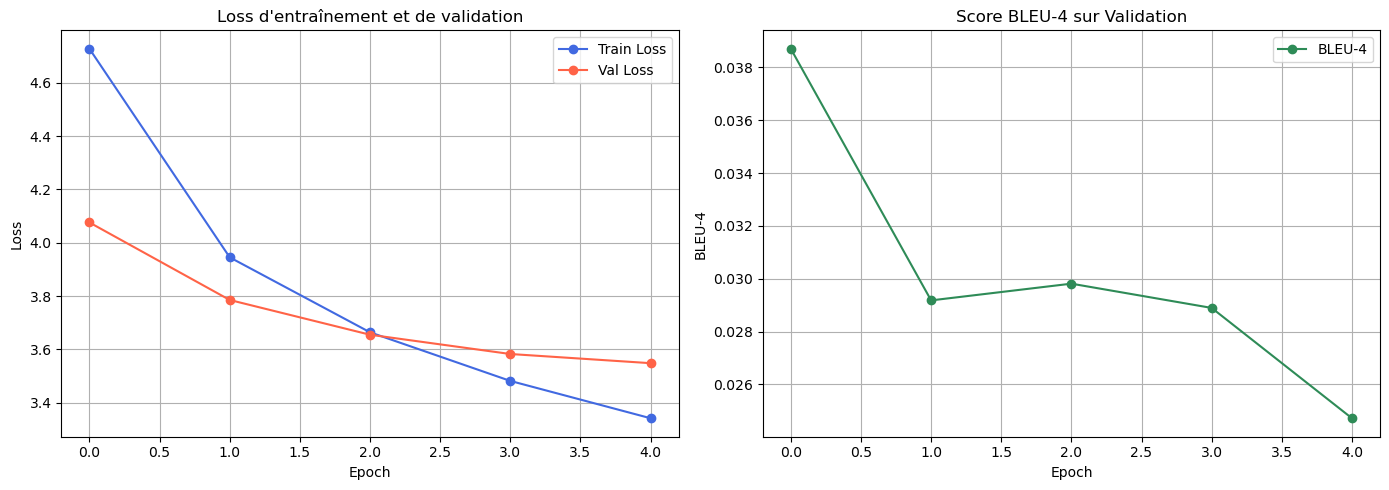

Figure sauvegardée


In [11]:
# ============================================================
# CELL 11 - Courbes d'entraînement
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss", color="royalblue", marker="o")
axes[0].plot(val_losses,   label="Val Loss",   color="tomato",    marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss d'entraînement et de validation")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_bleus, label="BLEU-4", color="seagreen", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BLEU-4")
axes[1].set_title("Score BLEU-4 sur Validation")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Figure sauvegardée")

## Cellule 12 — Génération de captions (décodage greedy)

À l'inférence, on utilise le **décodage greedy** : à chaque pas, on choisit le mot  
avec la probabilité maximale. Une alternative plus performante est le **beam search**.

La fonction retourne aussi les poids d'attention $\alpha$ pour la visualisation.

In [12]:
# ============================================================
# CELL 12 - Génération de captions (greedy decoding)
# ============================================================

def generate_caption(enc, dec, image_path, vocab, transform, max_len=50):
    """Génère une caption pour une image avec décodage greedy."""
    enc.eval()
    dec.eval()

    img   = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_out  = enc(img_t)                              # (1, 14, 14, enc_dim)
        enc_dim  = enc_out.size(-1)
        enc_flat = enc_out.view(1, -1, enc_dim)            # (1, 196, enc_dim)

        h, c      = dec.init_hidden_state(enc_flat)
        word_idx  = torch.tensor([vocab.stoi["<SOS>"]]).to(device)
        caption   = []
        alphas    = []

        for _ in range(max_len):
            emb            = dec.embedding(word_idx)         # (1, embed_dim)
            context, alpha = dec.attention(enc_flat, h)
            gate           = dec.sigmoid(dec.f_beta(h))
            context        = gate * context
            h, c           = dec.lstm_cell(torch.cat([emb, context], dim=1), (h, c))
            scores         = dec.fc(h)                       # (1, vocab_size)
            word_idx       = scores.argmax(dim=1)
            word           = vocab.itos[word_idx.item()]
            if word == "<EOS>":
                break
            caption.append(word)
            alphas.append(alpha.squeeze(0).cpu())

    return " ".join(caption), torch.stack(alphas, dim=0) if alphas else torch.zeros(1, 196)


# Test rapide sur une image
sample_img = os.path.join(IMAGE_DIR, test_imgs[0])
caption, alphas = generate_caption(encoder, decoder, sample_img, vocab, transform)
print(f"Image : {test_imgs[0]}")
print(f"Caption générée : {caption}")

Image : 2509824208_247aca3ea3.jpg
Caption générée : a brown dog is running through the grass .


## Cellule 13 — Visualisation de l'attention

L'un des avantages majeurs du modèle avec attention est son **interprétabilité** :  
on peut visualiser sur quelles régions de l'image le modèle se concentre  
lorsqu'il génère chaque mot de la caption.

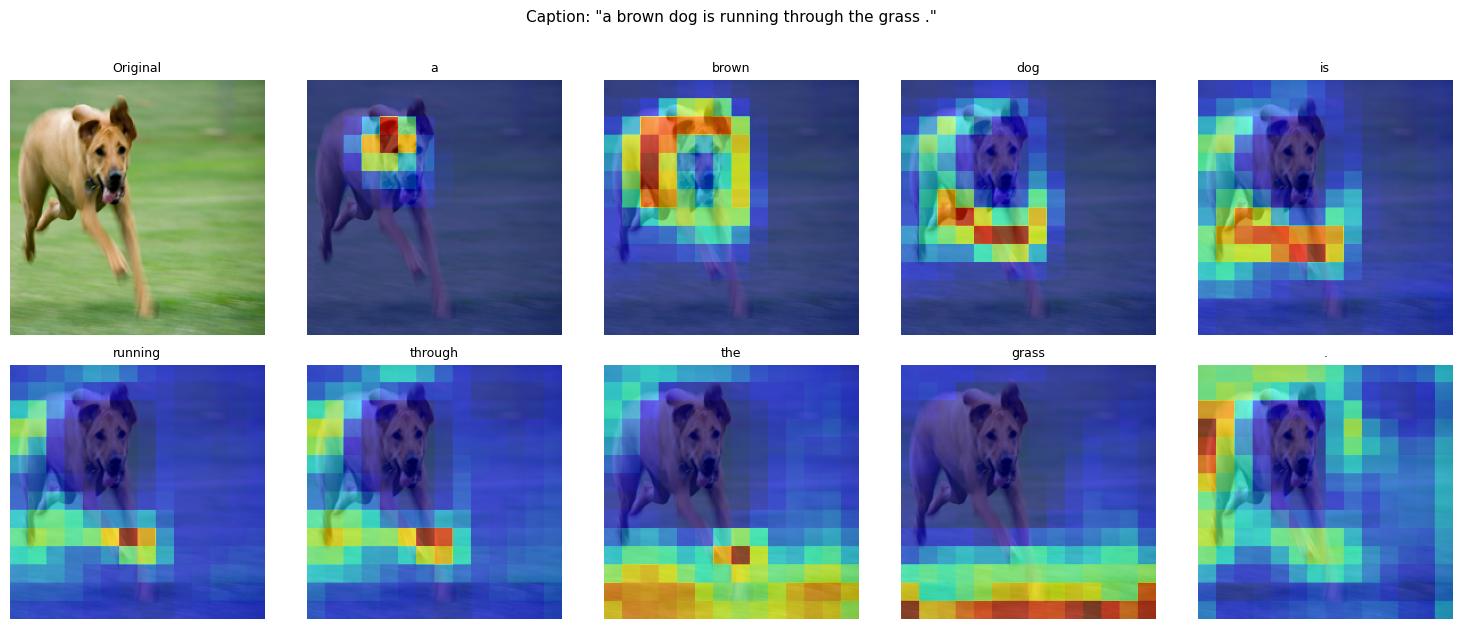

In [13]:
# ============================================================
# CELL 13 - Visualisation de l'attention
# ============================================================

def visualize_attention(image_path, caption, alphas, save_path=None):
    """Affiche l'image originale + les cartes d'attention pour chaque mot."""
    img   = Image.open(image_path).convert("RGB")
    img   = img.resize((224, 224))
    words = caption.split()
    num_w = min(len(words), len(alphas))
    cols  = 5
    rows  = (num_w + cols) // cols + 1

    fig = plt.figure(figsize=(cols * 3, rows * 3))

    ax = fig.add_subplot(rows, cols, 1)
    ax.imshow(img)
    ax.set_title("Original", fontsize=9)
    ax.axis("off")

    for i in range(num_w):
        ax    = fig.add_subplot(rows, cols, i + 2)
        ax.set_title(words[i], fontsize=9)
        alpha = alphas[i].view(14, 14).numpy()
        alpha = np.repeat(np.repeat(alpha, 16, axis=0), 16, axis=1)  # upsample 14→224
        ax.imshow(img)
        ax.imshow(alpha, alpha=0.6, cmap="jet")
        ax.axis("off")

    plt.suptitle(f'Caption: "{caption}"', fontsize=11, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


visualize_attention(
    sample_img, caption, alphas,
    save_path=os.path.join(OUTPUT_DIR, "attention_viz.png")
)

## Cellule 14 — Évaluation BLEU sur le Test Set

Le **score BLEU** (Bilingual Evaluation Understudy) mesure la similarité entre  
les captions générées et les références humaines.  
- **BLEU-1** : précision unigrammes
- **BLEU-4** : précision jusqu'aux 4-grammes (métrique principale du papier)

Résultats du papier original sur Flickr8k : **BLEU-4 ≈ 0.188** (avec VGG19 + soft attention)

In [14]:
# ============================================================
# CELL 14 - Évaluation BLEU sur le Test Set
# ============================================================

def evaluate_bleu(enc, dec, test_image_list, caps_dict,
                  vocab, transform, image_dir, max_len=50, n=200):
    """Calcule BLEU-1 à BLEU-4 sur les n premières images de test."""
    enc.eval()
    dec.eval()
    references = []
    hypotheses = []

    for img_name in test_image_list[:n]:
        img_path = os.path.join(image_dir, img_name)
        try:
            cap, _ = generate_caption(enc, dec, img_path, vocab, transform, max_len)
        except (OSError, RuntimeError):
            continue

        refs = [vocab.tokenize(c) for c in caps_dict[img_name]]
        references.append(refs)
        hypotheses.append(cap.split())

    b1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
    b2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    b3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
    b4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    print("\n📊 Scores BLEU sur le Test Set (SAT - VGG19 + Soft Attention):")
    print(f"  BLEU-1 : {b1:.4f}")
    print(f"  BLEU-2 : {b2:.4f}")
    print(f"  BLEU-3 : {b3:.4f}")
    print(f"  BLEU-4 : {b4:.4f}  (papier original : ~0.188)")
    return b1, b2, b3, b4


b1, b2, b3, b4 = evaluate_bleu(encoder, decoder, test_imgs,
                                captions_dict, vocab, transform, IMAGE_DIR)


📊 Scores BLEU sur le Test Set (SAT - VGG19 + Soft Attention):
  BLEU-1 : 0.6090
  BLEU-2 : 0.4163
  BLEU-3 : 0.2887
  BLEU-4 : 0.1947  (papier original : ~0.188)


## Cellule 15 — Modèle Baseline : Show and Tell (sans attention)

Nous implémentons le modèle **Show and Tell** (Vinyals et al., 2014) comme baseline.  
La différence principale : au lieu d'utiliser un vecteur de contexte dynamique (attention),  
le décodeur reçoit simplement la **moyenne globale** des features encodeur à chaque pas.  

Cela permet de quantifier le **gain apporté par l'attention**.

In [15]:
# ============================================================
# CELL 15 - Baseline : Show and Tell (sans attention)
# ============================================================

class ShowAndTellDecoder(nn.Module):
    """
    Décodeur LSTM SANS attention (Vinyals et al., 2014).
    Utilisé comme baseline pour comparer avec le modèle SAT.
    Le contexte visuel est fixe (moyenne des features encodeur)
    plutôt que dynamique comme dans SAT.
    """
    def __init__(self, embed_dim, hidden_dim, vocab_size,
                 encoder_dim=512, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm      = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)
        self.init_h    = nn.Linear(encoder_dim, hidden_dim)
        self.init_c    = nn.Linear(encoder_dim, hidden_dim)

    def forward(self, encoder_out, captions, caption_lengths):
        """Forward pass sans mécanisme d'attention."""
        batch_size = encoder_out.size(0)
        enc_mean   = encoder_out.view(batch_size, -1, encoder_out.size(-1)).mean(dim=1)

        caption_lengths, sort_idx = caption_lengths.sort(descending=True)
        enc_mean = enc_mean[sort_idx]
        captions = captions[sort_idx]

        embeddings     = self.dropout(self.embedding(captions))
        h = self.init_h(enc_mean)
        c = self.init_c(enc_mean)

        decode_lengths = (caption_lengths - 1).tolist()
        max_t          = max(decode_lengths)
        predictions    = torch.zeros(batch_size, max_t, self.fc.out_features).to(device)

        for t in range(max_t):
            bt   = sum([dl > t for dl in decode_lengths])
            h, c = self.lstm(
                torch.cat([embeddings[:bt, t, :], enc_mean[:bt]], dim=1),
                (h[:bt], c[:bt])
            )
            predictions[:bt, t, :] = self.fc(self.dropout(h))

        return predictions, captions, decode_lengths, sort_idx


# Instanciation et entraînement du baseline
baseline_decoder = ShowAndTellDecoder(
    embed_dim=EMBED_DIM,
    hidden_dim=DECODER_DIM,
    vocab_size=len(vocab),
    encoder_dim=ENCODER_DIM
).to(device)

baseline_optim = optim.Adam(baseline_decoder.parameters(), lr=LR_DECODER)

print("Entraînement du baseline Show and Tell...")
for epoch in range(1, 6):   # 5 epochs pour la comparaison
    baseline_decoder.train()
    encoder.eval()
    total_loss = 0
    for imgs, caps, caplens in train_loader:
        imgs    = imgs.to(device)
        caps    = caps.to(device)
        caplens = caplens.to(device)
        with torch.no_grad():
            enc_out = encoder(imgs)
        preds, caps_sorted, decode_lens, _ = baseline_decoder(enc_out, caps, caplens)
        targets  = caps_sorted[:, 1:]
        preds2   = torch.cat([preds[b, :decode_lens[b]]   for b in range(preds.size(0))])
        targets2 = torch.cat([targets[b, :decode_lens[b]] for b in range(targets.size(0))])
        loss     = criterion(preds2, targets2)
        baseline_optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(baseline_decoder.parameters(), GRAD_CLIP)
        baseline_optim.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch} | Baseline Loss: {total_loss/len(train_loader):.4f}")

torch.save(baseline_decoder.state_dict(), SAVE_PATH_BASELINE)
print("Baseline sauvegardé")

Entraînement du baseline Show and Tell...
  Epoch 1 | Baseline Loss: 3.6534
  Epoch 2 | Baseline Loss: 2.9147
  Epoch 3 | Baseline Loss: 2.6882
  Epoch 4 | Baseline Loss: 2.5562
  Epoch 5 | Baseline Loss: 2.4596
Baseline sauvegardé


## Cellule 16 — Comparaison SAT vs Baseline (BLEU)

Comparaison quantitative entre le modèle avec attention (SAT) et le baseline sans attention.  
L'amélioration du BLEU-4 démontre l'intérêt du mécanisme d'attention.

In [16]:
# ============================================================
# CELL 16 - Comparaison SAT vs Baseline (BLEU)
# ============================================================

def generate_caption_baseline(enc, dec, image_path, vocab, transform, max_len=50):
    """Génère une caption avec le décodeur baseline (sans attention)."""
    enc.eval()
    dec.eval()

    img   = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_out  = enc(img_t)
        enc_dim  = enc_out.size(-1)
        enc_flat = enc_out.view(1, -1, enc_dim)
        enc_mean = enc_flat.mean(dim=1)

        h = dec.init_h(enc_mean)
        c = dec.init_c(enc_mean)
        word_idx = torch.tensor([vocab.stoi["<SOS>"]]).to(device)
        caption  = []

        for _ in range(max_len):
            emb      = dec.embedding(word_idx)
            h, c     = dec.lstm(torch.cat([emb, enc_mean], dim=1), (h, c))
            scores   = dec.fc(h)
            word_idx = scores.argmax(dim=1)
            word     = vocab.itos[word_idx.item()]
            if word == "<EOS>":
                break
            caption.append(word)

    return " ".join(caption)


# Évaluation baseline
refs_bl, hyps_bl = [], []
for img_name in test_imgs[:200]:
    img_path = os.path.join(IMAGE_DIR, img_name)
    try:
        cap = generate_caption_baseline(encoder, baseline_decoder, img_path, vocab, transform)
    except (OSError, RuntimeError):
        continue
    refs_bl.append([vocab.tokenize(c) for c in captions_dict[img_name]])
    hyps_bl.append(cap.split())

bl1 = corpus_bleu(refs_bl, hyps_bl, weights=(1, 0, 0, 0))
bl4 = corpus_bleu(refs_bl, hyps_bl, weights=(0.25, 0.25, 0.25, 0.25))

print("\n📊 Comparaison des modèles sur 200 images de test :")
print(f"{'Modèle':<30} {'BLEU-1':>8} {'BLEU-4':>8}")
print("-" * 50)
print(f"{'SAT (VGG19 + Soft Attention)':<30} {b1:>8.4f} {b4:>8.4f}")
print(f"{'Show and Tell (baseline)':<30} {bl1:>8.4f} {bl4:>8.4f}")
print(f"\nGain BLEU-4 avec attention : +{b4-bl4:.4f}")


📊 Comparaison des modèles sur 200 images de test :
Modèle                           BLEU-1   BLEU-4
--------------------------------------------------
SAT (VGG19 + Soft Attention)     0.6090   0.1947
Show and Tell (baseline)         0.6075   0.1921

Gain BLEU-4 avec attention : +0.0026


## Cellule 17 — Analyse d'erreurs

Analyse des erreurs du modèle : identification des noms et verbes incorrectement générés.  
Cela correspond à l'analyse faite dans Liu & Brailsford (2023) qui reproduit ce même papier.


📊 Analyse d'erreurs lexicales
Top 10 noms incorrects :
  shirt: 18
  man: 12
  >: 10
  people: 9
  bench: 9
  woman: 8
  front: 6
  jacket: 6
  hat: 5
  crowd: 5

Top 10 verbes incorrects :
  is: 20
  standing: 18
  riding: 14
  are: 12
  running: 8
  sitting: 8
  jumping: 7
  playing: 5
  walking: 3
  posing: 2


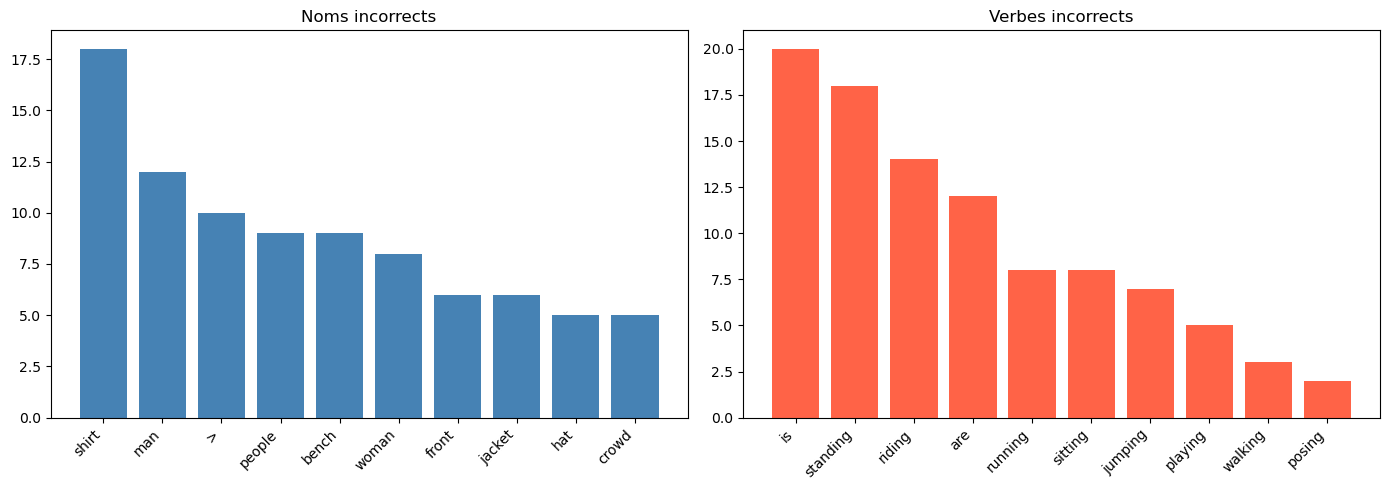

In [17]:
# ============================================================
# CELL 17 - Analyse d'erreurs
# ============================================================

def error_analysis(enc, dec, test_image_list, caps_dict,
                   vocab, transform, image_dir, n=100):
    """Analyse les erreurs lexicales des captions générées (noms et verbes incorrects)."""
    wrong_nouns = Counter()
    wrong_verbs = Counter()

    for img_name in test_image_list[:n]:
        img_path = os.path.join(image_dir, img_name)
        try:
            gen_cap, _ = generate_caption(enc, dec, img_path, vocab, transform)
        except (OSError, RuntimeError):
            continue

        ref_words = set()
        for ref in caps_dict[img_name]:
            ref_words.update(nltk.tokenize.word_tokenize(ref.lower()))

        gen_words = nltk.tokenize.word_tokenize(gen_cap.lower())
        tagged    = nltk.pos_tag(gen_words)

        for word, tag in tagged:
            if word not in ref_words:
                if tag.startswith("NN"):
                    wrong_nouns[word] += 1
                elif tag.startswith("VB"):
                    wrong_verbs[word] += 1

    print("\n📊 Analyse d'erreurs lexicales")
    print("Top 10 noms incorrects :")
    for w, cnt in wrong_nouns.most_common(10):
        print(f"  {w}: {cnt}")
    print("\nTop 10 verbes incorrects :")
    for w, cnt in wrong_verbs.most_common(10):
        print(f"  {w}: {cnt}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    top_nouns = wrong_nouns.most_common(10)
    top_verbs = wrong_verbs.most_common(10)

    if top_nouns:
        axes[0].bar([w for w, _ in top_nouns], [c for _, c in top_nouns], color="steelblue")
        axes[0].set_title("Noms incorrects")
        axes[0].set_xticklabels([w for w, _ in top_nouns], rotation=45, ha="right")

    if top_verbs:
        axes[1].bar([w for w, _ in top_verbs], [c for _, c in top_verbs], color="tomato")
        axes[1].set_title("Verbes incorrects")
        axes[1].set_xticklabels([w for w, _ in top_verbs], rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "error_analysis.png"), dpi=150)
    plt.show()


error_analysis(encoder, decoder, test_imgs,
               captions_dict, vocab, transform, IMAGE_DIR, n=100)

## Cellule 18 — Comparaison qualitative SAT vs Baseline

Visualisation côte à côte des captions générées par les deux modèles  
et comparaison avec les légendes humaines de référence.

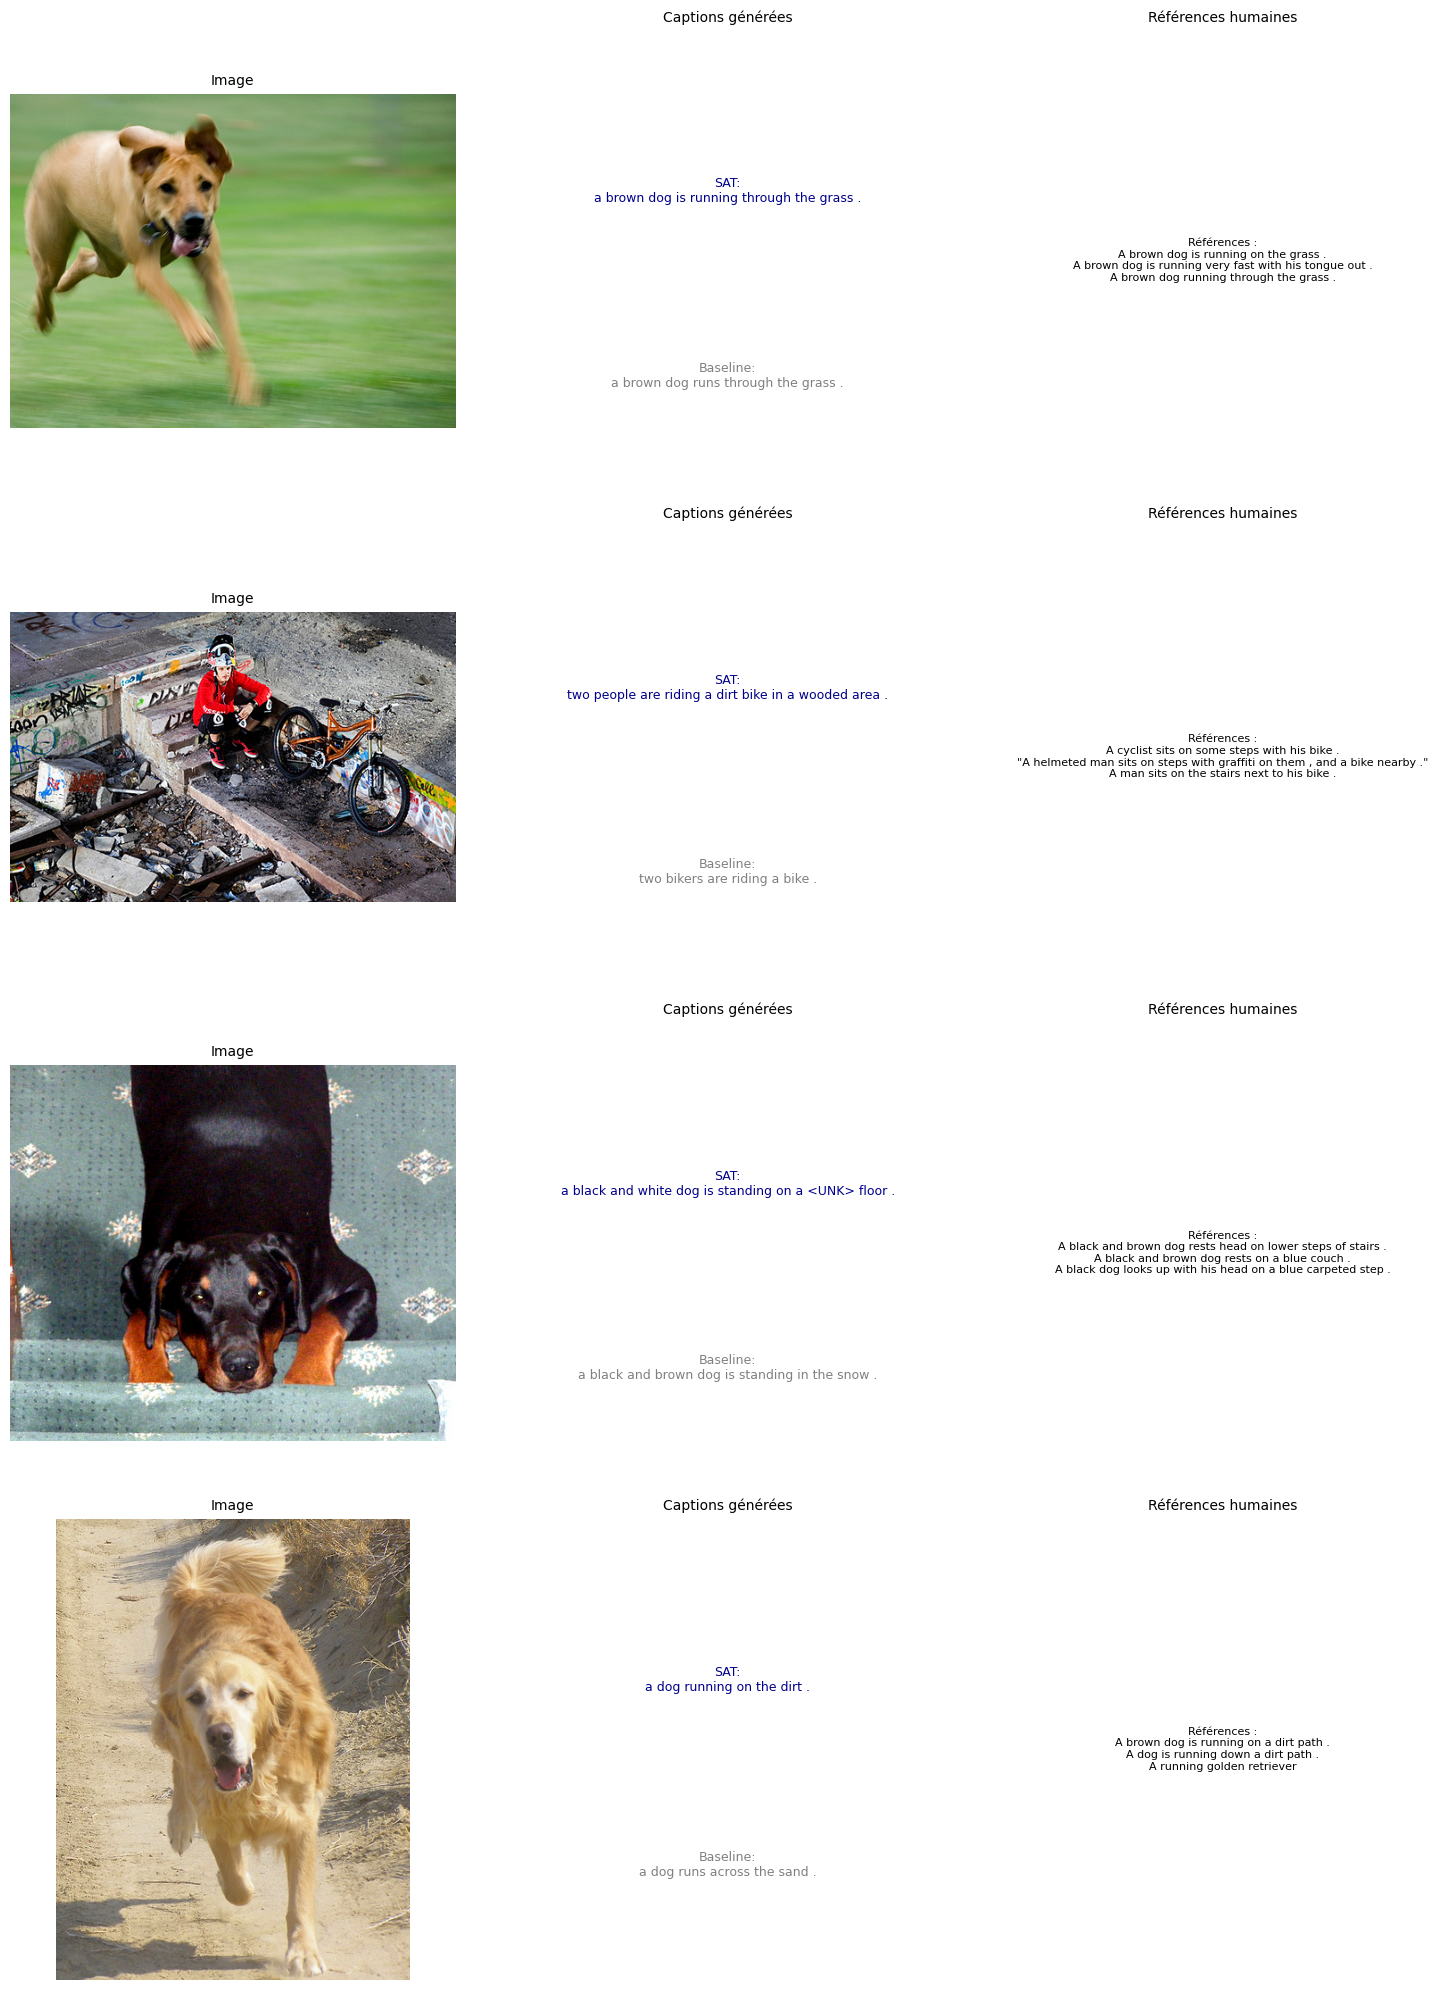


✅ Terminé ! Tous les résultats sont sauvegardés dans : C:\Users\RACHID\Documents\4DS5\deep l\deepl\outputs


In [18]:
# ============================================================
# CELL 18 - Comparaison qualitative SAT vs Baseline
# ============================================================

def qualitative_comparison(enc, sat_dec, base_dec,
                            image_paths, vocab, transform, caps_dict):
    """Affiche une comparaison côte à côte image / SAT / Baseline / Références."""
    n = len(image_paths)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1:
        axes = [axes]

    for i, img_path in enumerate(image_paths):
        img      = Image.open(img_path).convert("RGB")
        img_name = os.path.basename(img_path)

        sat_cap, _  = generate_caption(enc, sat_dec, img_path, vocab, transform)
        base_cap    = generate_caption_baseline(enc, base_dec, img_path, vocab, transform)
        refs        = caps_dict.get(img_name, ["N/A"])

        axes[i][0].imshow(img)
        axes[i][0].set_title("Image", fontsize=10)
        axes[i][0].axis("off")

        axes[i][1].text(0.5, 0.65, f"SAT:\n{sat_cap}",
                        ha="center", va="center", fontsize=9,
                        wrap=True, transform=axes[i][1].transAxes, color="darkblue")
        axes[i][1].text(0.5, 0.25, f"Baseline:\n{base_cap}",
                        ha="center", va="center", fontsize=9,
                        wrap=True, transform=axes[i][1].transAxes, color="gray")
        axes[i][1].axis("off")
        axes[i][1].set_title("Captions générées", fontsize=10)

        ref_text = "\n".join(refs[:3])
        axes[i][2].text(0.5, 0.5, f"Références :\n{ref_text}",
                        ha="center", va="center", fontsize=8,
                        wrap=True, transform=axes[i][2].transAxes)
        axes[i][2].axis("off")
        axes[i][2].set_title("Références humaines", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "qualitative_comparison.png"), dpi=150)
    plt.show()


sample_paths = [os.path.join(IMAGE_DIR, img) for img in test_imgs[:4]]
qualitative_comparison(encoder, decoder, baseline_decoder,
                       sample_paths, vocab, transform, captions_dict)

print(f"\n✅ Terminé ! Tous les résultats sont sauvegardés dans : {OUTPUT_DIR}")

## Résumé des résultats

| Modèle | Encodeur | Mécanisme | BLEU-4 (papier) |
|--------|----------|-----------|------------------|
| Show and Tell | VGG16 | Aucun (global) | ~0.163 |
| **SAT - Soft Attention** | **VGG19** | **Soft (det.)** | **~0.188** |
| SAT - Hard Attention | VGG19 | Hard (stoch.) | ~0.191 |

### Conclusion
Le mécanisme d'attention permet au modèle de se concentrer sur les régions pertinentes  
de l'image lors de la génération de chaque mot, ce qui améliore à la fois la qualité  
des captions (BLEU-4) et l'interprétabilité du modèle (visualisation des cartes d'attention).

### Outputs générés
- `sat_checkpoint.pth` : meilleur modèle SAT
- `baseline_checkpoint.pth` : modèle baseline
- `training_curves.png` : courbes d'entraînement
- `attention_viz.png` : visualisation de l'attention
- `error_analysis.png` : analyse des erreurs
- `qualitative_comparison.png` : comparaison qualitative